# Bradley–Terry per-person analysis

Fits a plain Bradley–Terry model per person on `food_rescue_combined copy.csv`, then computes sx/sy scores for each comparison pair.

**Features used:** size, access, income, poverty, last_donation, dist  
**Dropped:** total_donation (scale inconsistency)

**Sign corrections** (so higher processed value = higher donation priority):
| Feature | Raw direction | Sign | Rationale |
|---|---|---|---|
| size | 0–4 | +1 | Larger org serves more clients |
| access | 0–2 | +1 | Higher = worse food access = more need |
| income | 0–5 | −1 | Higher index = richer = less need |
| poverty | 0–7 | +1 | Higher = more poverty = more need |
| last_donation | 0–12 | −1 | Higher = more recent = less urgency |
| dist | 0–3 | −1 | Higher = farther = less convenient |


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import expit
from scipy.optimize import minimize

df = pd.read_csv('food_rescue_combined copy.csv')

FEATURES = ['size', 'access', 'income', 'poverty', 'last_donation', 'dist']
# +1 = keep (higher raw = higher priority), -1 = flip
SIGN = np.array([1, 1, -1, 1, -1, -1], dtype=float)

# Global min/max for normalisation (computed once across all rows)
all_vals = np.concatenate([
    df[[f+'_A' for f in FEATURES]].values,
    df[[f+'_B' for f in FEATURES]].values
], axis=0)
F_MIN = all_vals.min(axis=0)   # shape (6,)
F_MAX = all_vals.max(axis=0)   # shape (6,)
print('Global feature ranges (raw):')
for i, f in enumerate(FEATURES):
    print(f'  {f:15s}  [{F_MIN[i]:.0f}, {F_MAX[i]:.0f}]')


Global feature ranges (raw):
  size             [0, 4]
  access           [0, 2]
  income           [0, 5]
  poverty          [0, 7]
  last_donation    [0, 12]
  dist             [0, 3]


In [2]:
def process_features(raw):
    """Normalise to [0,1] then sign-correct so higher = higher donation priority."""
    rng = np.where(F_MAX > F_MIN, F_MAX - F_MIN, 1.0)
    normed = (raw - F_MIN) / rng
    # SIGN=-1: flip so low raw value -> high priority score
    signed = np.where(SIGN == 1, normed, 1.0 - normed)
    return signed   # all in [0, 1], higher = more deserving of donation


def simplex_project(w):
    """Project onto probability simplex: clip negatives, normalise."""
    w_pos = np.clip(w, 0, None)
    total = w_pos.sum()
    if total == 0:
        return np.ones(len(w)) / len(w)
    return w_pos / total


def fit_plain_bt(dx, y):
    """Fit plain BT: P(y=1) = sigmoid(dx @ w), no intercept. Returns w."""
    w0 = np.zeros(dx.shape[1])

    def nll(w):
        z = dx @ w
        return float(np.sum(np.logaddexp(0, z) - y * z))

    def grad(w):
        z = dx @ w
        p = expit(z)
        return dx.T @ (p - y)

    res = minimize(nll, w0, jac=grad, method='L-BFGS-B',
                   options={'maxiter': 2000, 'ftol': 1e-15, 'gtol': 1e-9})
    if not res.success:
        import warnings
        warnings.warn(f'BT optimiser: {res.message}')
    return res.x


print('Helper functions defined.')


Helper functions defined.


In [3]:
# Pre-process all feature columns globally
xA_all = process_features(df[[f+'_A' for f in FEATURES]].values)  # (N, 6)
xB_all = process_features(df[[f+'_B' for f in FEATURES]].values)  # (N, 6)
dx_all = xA_all - xB_all                                           # (N, 6)  A minus B

# For sx/sy normalisation: max |dx| per feature across all comparisons
DX_SCALE = np.abs(dx_all).max(axis=0)                              # (6,)
DX_SCALE = np.where(DX_SCALE > 0, DX_SCALE, 1.0)

df['y'] = (df['AorB'] == 'A').astype(float)   # 1 = chose A

# Store processed diffs in df for per-person slicing
for i, f in enumerate(FEATURES):
    df[f'dx_{f}'] = dx_all[:, i]

persons = sorted(df['personID'].unique())
print(f'{len(persons)} persons: {persons}')


19 persons: ['D1', 'D2', 'D5', 'F1', 'F2', 'R1', 'R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8', 'V1', 'V2', 'V3', 'V5', 'V6', 'V7']


In [4]:
results = {}   # person_id -> dict with omega, sx, sy, kappa, r, acc, ...
dx_cols = [f'dx_{f}' for f in FEATURES]

for pid in persons:
    sub   = df[df['personID'] == pid].copy()
    dx    = sub[dx_cols].values    # (T, 6)
    y     = sub['y'].values        # (T,)

    # Fit BT
    w_hat = fit_plain_bt(dx, y)
    omega = simplex_project(w_hat)

    # In-sample accuracy
    acc = ((dx @ w_hat >= 0).astype(float) == y).mean()

    # sx / sy: normalise diffs so each feature is in [-1, 1]
    dx_norm = dx / DX_SCALE
    r     = (np.abs(dx_norm) * omega).sum(axis=1)  # unsigned intensity
    kappa = (dx_norm * omega).sum(axis=1)           # signed preference (+->A, -->B)
    sy    = (r + kappa) / 2   # score of A  = s(A, B)
    sx    = (r - kappa) / 2   # score of B  = s(B, A)

    results[pid] = dict(w_hat=w_hat, omega=omega,
                        r=r, kappa=kappa, sy=sy, sx=sx,
                        acc=acc, T=len(y),
                        choice=sub['AorB'].values, sub=sub)

print('BT fits complete.\n')
header = '  '.join(f'{f[:5]:>6s}' for f in FEATURES)
print(f'{"Person":8s}  {"T":>4s}  {"Acc":>6s}  {header}')
for pid, res in results.items():
    om = '  '.join(f'{v:6.3f}' for v in res['omega'])
    print(f'{pid:8s}  {res["T"]:>4d}  {res["acc"]:>5.1%}  {om}')


BT fits complete.

Person       T     Acc    size   acces   incom   pover   last_    dist
D1          47  91.5%   0.221   0.390   0.047   0.319   0.000   0.023
D2          45  80.0%   0.179   0.275   0.000   0.367   0.030   0.149
D5          49  95.9%   0.037   0.000   0.633   0.114   0.057   0.158
F1          45  82.2%   0.000   0.013   0.000   0.645   0.000   0.343
F2          45  86.7%   0.255   0.049   0.113   0.188   0.000   0.394
R1          40  95.0%   0.035   0.098   0.155   0.617   0.096   0.000
R2          45  88.9%   0.498   0.303   0.000   0.059   0.050   0.091
R3          47  89.4%   0.365   0.179   0.154   0.000   0.081   0.222
R4          45  91.1%   0.006   0.225   0.281   0.488   0.000   0.000
R5          45  71.1%   0.300   0.071   0.000   0.029   0.000   0.600
R6          48  89.6%   0.026   0.154   0.820   0.000   0.000   0.000
R7          47  87.2%   0.000   0.161   0.000   0.523   0.116   0.201
R8          47  100.0%   0.000   0.206   0.000   0.489   0.073   0.232

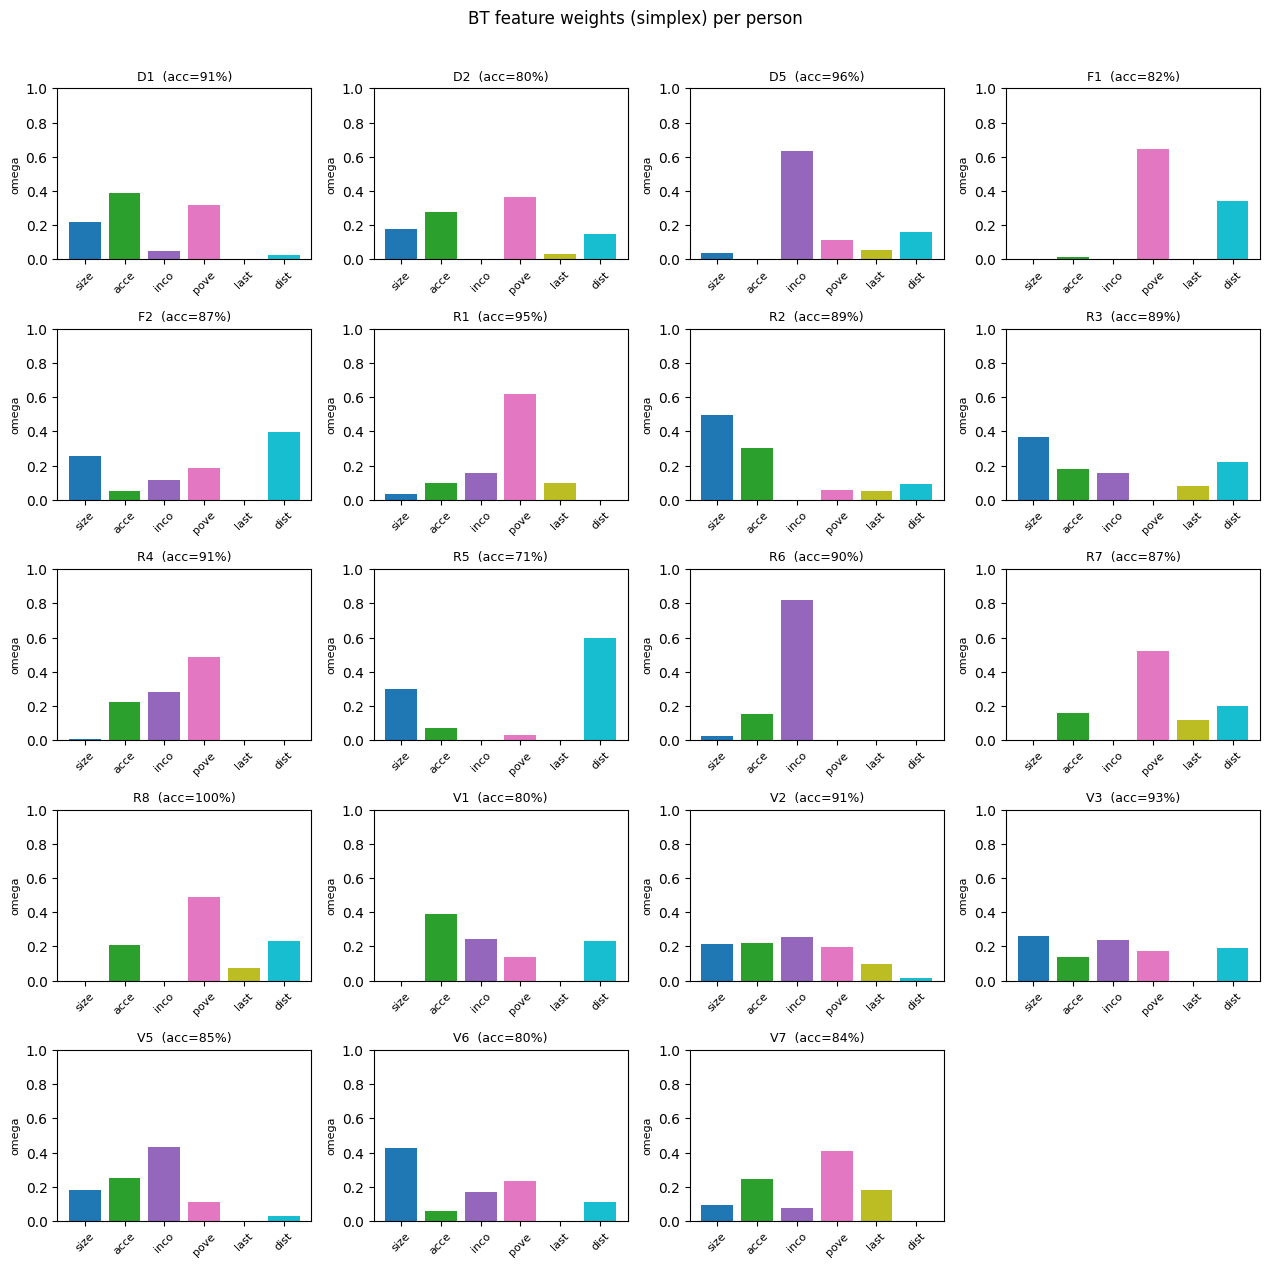

Saved bt_omega_per_person.png


In [5]:
n = len(persons)
ncols, nrows = 4, (n + 3) // 4
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.2, nrows * 2.5))
axes = axes.flatten()

colors = plt.cm.tab10(np.linspace(0, 1, len(FEATURES)))

for ax, pid in zip(axes, persons):
    omega = results[pid]['omega']
    ax.bar(range(len(FEATURES)), omega, color=colors)
    ax.set_xticks(range(len(FEATURES)))
    ax.set_xticklabels([f[:4] for f in FEATURES], fontsize=8, rotation=45)
    ax.set_ylim(0, 1)
    ax.set_title(f'{pid}  (acc={results[pid]["acc"]:.0%})', fontsize=9)
    ax.set_ylabel('omega', fontsize=8)

for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle('BT feature weights (simplex) per person', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('bt_omega_per_person.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved bt_omega_per_person.png')


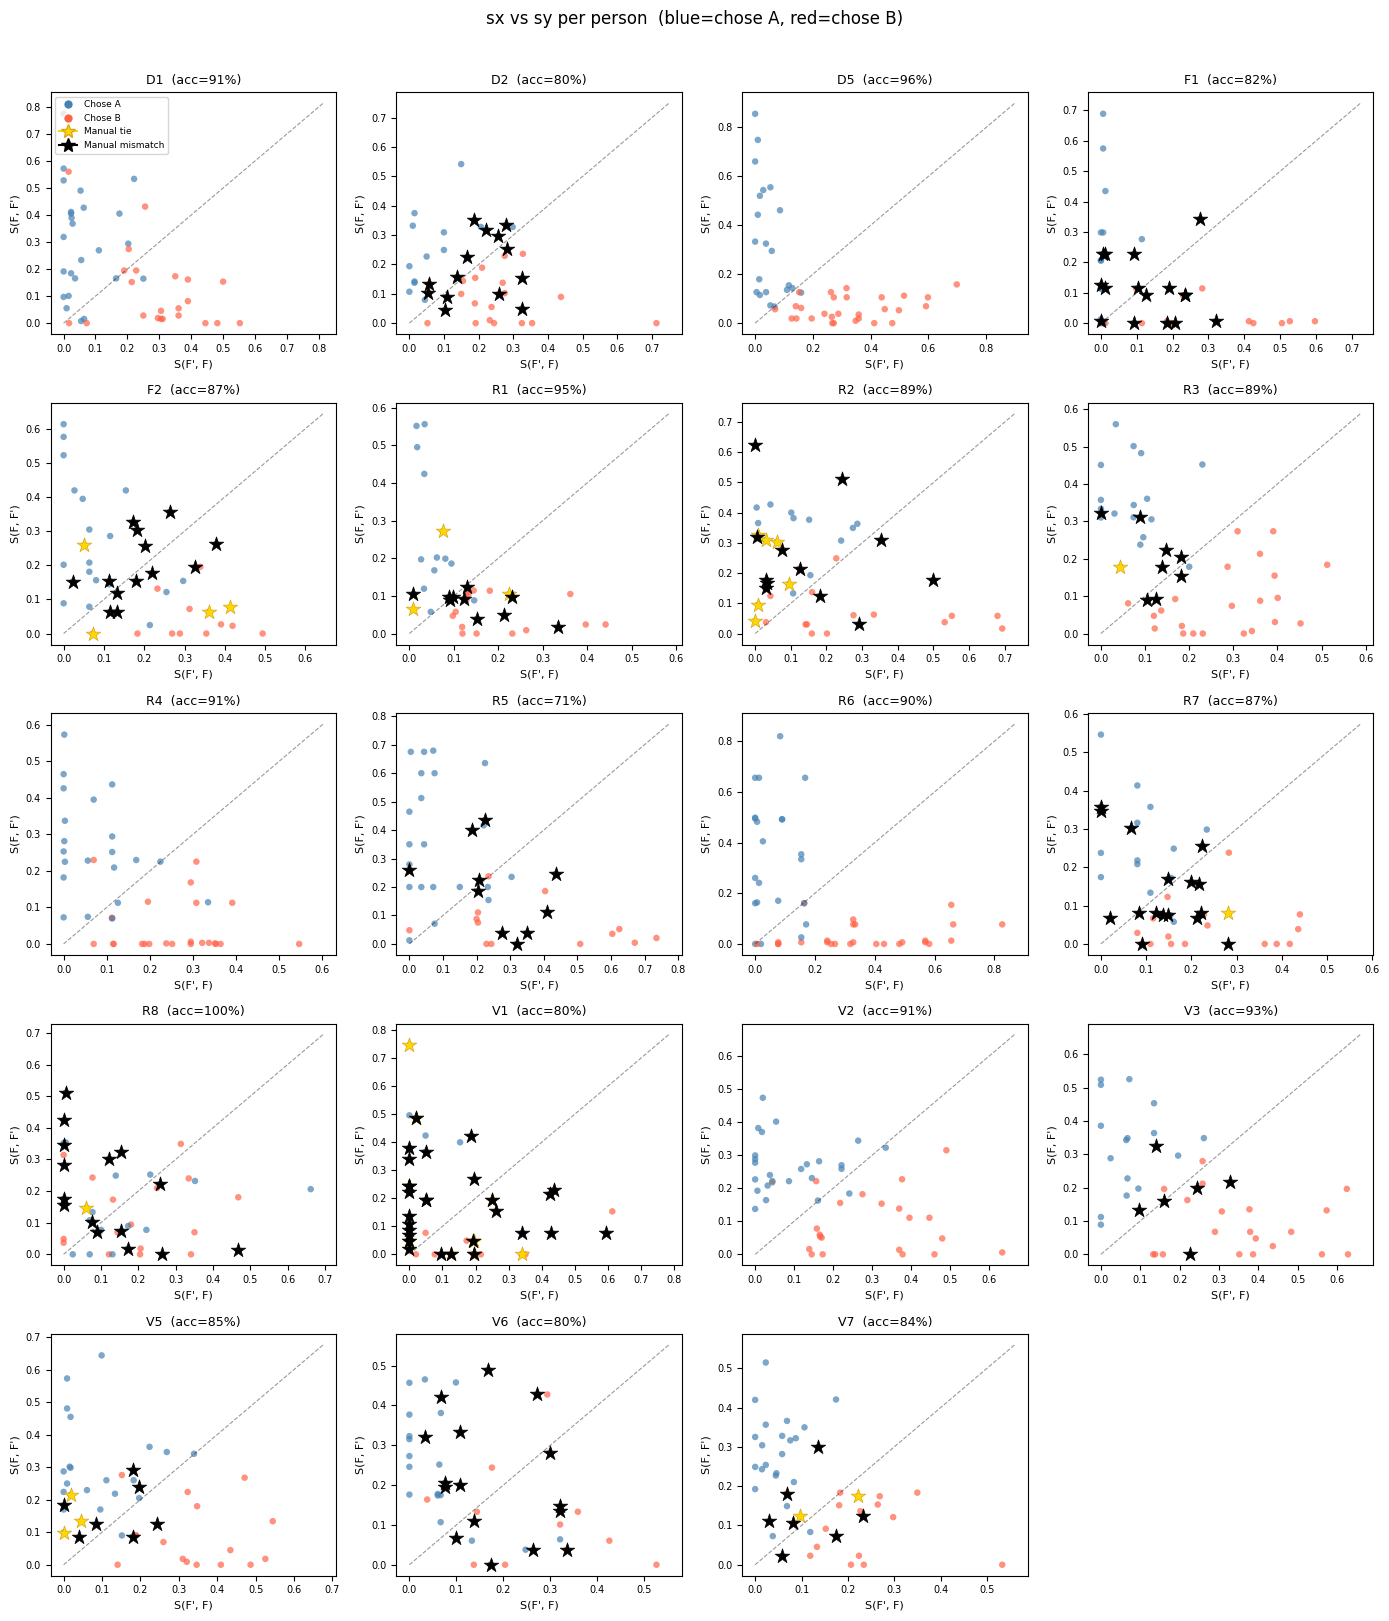

Saved bt_sxsy_per_person.png


In [6]:
from matplotlib.lines import Line2D
import pandas as pd

ties_df      = pd.read_csv('ties.csv')[['personID','num_Q']]
mismatch_df  = pd.read_csv('mismatches.csv')[['personID','num_Q']]

ncols, nrows = 4, (n + 3) // 4
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3.2))
axes = axes.flatten()

choice_color = {'A': 'steelblue', 'B': 'tomato'}

for ax, pid in zip(axes, persons):
    res = results[pid]
    sx, sy   = res['sx'], res['sy']
    sub_idx  = res['sub']['num_Q'].values
    choice   = res['choice']
    colors_pt = [choice_color.get(c, 'gray') for c in choice]

    # Base scatter
    ax.scatter(sx, sy, c=colors_pt, alpha=0.7, s=22, linewidths=0)

    # y=x reference line
    lim = max(sx.max(), sy.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'k--', lw=0.8, alpha=0.4)

    # Tied queries: yellow star
    tie_qs = set(ties_df[ties_df['personID'] == pid]['num_Q'])
    tie_mask = np.isin(sub_idx, list(tie_qs))
    if tie_mask.any():
        ax.scatter(sx[tie_mask], sy[tie_mask],
                   marker='*', s=120, color='gold',
                   edgecolors='goldenrod', linewidths=0.5, zorder=5)

    # Mismatched queries: black star
    mis_qs = set(mismatch_df[mismatch_df['personID'] == pid]['num_Q'])
    mis_mask = np.isin(sub_idx, list(mis_qs))
    if mis_mask.any():
        ax.scatter(sx[mis_mask], sy[mis_mask],
                   marker='*', s=120, color='black',
                   edgecolors='black', linewidths=0.5, zorder=6)

    ax.set_xlabel("S(F', F)", fontsize=8)
    ax.set_ylabel("S(F, F')", fontsize=8)
    ax.set_title(f'{pid}  (acc={res["acc"]:.0%})', fontsize=9)
    ax.tick_params(labelsize=7)

legend_els = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue',
           markersize=7, label='Chose A'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='tomato',
           markersize=7, label='Chose B'),
    Line2D([0],[0], marker='*', color='gold', markeredgecolor='goldenrod',
           markersize=10, label='Manual tie'),
    Line2D([0],[0], marker='*', color='black',
           markersize=10, label='Manual mismatch'),
]
axes[0].legend(handles=legend_els, fontsize=6.5, loc='upper left')

for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle('sx vs sy per person  (blue=chose A, red=chose B)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('bt_sxsy_per_person.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved bt_sxsy_per_person.png')


In [7]:
# Save per-comparison scores to CSV
rows = []
for pid, res in results.items():
    sub = res['sub'].copy()
    sub['r']      = res['r']
    sub['kappa']  = res['kappa']
    sub['sy']     = res['sy']
    sub['sx']     = res['sx']
    sub['bt_pred'] = np.where(res['sy'] > res['sx'], 'A', 'B')
    rows.append(sub)

out = pd.concat(rows, ignore_index=True)
keep_cols = ['personID','num_Q','AorB','food',
             'size_A','access_A','income_A','poverty_A','last_donation_A','dist_A',
             'size_B','access_B','income_B','poverty_B','last_donation_B','dist_B',
             'r','kappa','sy','sx','bt_pred']
out = out[keep_cols]
out.to_csv('bt_scores.csv', index=False)
print(f'Saved bt_scores.csv  ({len(out)} rows)')

# Overall BT prediction accuracy
acc_overall = (out['bt_pred'] == out['AorB']).mean()
print(f'Overall BT accuracy: {acc_overall:.1%}\n')

print(out[['personID','r','kappa','sy','sx']].groupby('personID').mean().round(3))


Saved bt_scores.csv  (865 rows)
Overall BT accuracy: 83.6%

              r  kappa     sy     sx
personID                            
D1        0.389  0.044  0.216  0.172
D2        0.357 -0.025  0.166  0.191
D5        0.386 -0.032  0.177  0.209
F1        0.263 -0.020  0.121  0.141
F2        0.366  0.003  0.185  0.182
R1        0.268 -0.003  0.132  0.136
R2        0.381  0.036  0.209  0.172
R3        0.381  0.020  0.201  0.180
R4        0.316 -0.023  0.146  0.169
R5        0.451  0.026  0.238  0.212
R6        0.402 -0.052  0.175  0.227
R7        0.303 -0.025  0.139  0.164
R8        0.313  0.002  0.158  0.155
V1        0.322  0.020  0.171  0.151
V2        0.377 -0.001  0.188  0.189
V3        0.411 -0.042  0.185  0.226
V5        0.381  0.017  0.199  0.182
V6        0.357  0.052  0.204  0.153
V7        0.318  0.069  0.194  0.124


In [8]:
# Translate manual scoring tables into approximate omega vectors.
# For each person & feature, omega_f ∝ range(manual scores for f).
# Intuition: a feature with a wider score range can swing a pairwise
# comparison more — so it contributes more weight in the linear model.

FEAT_CSV = {
    'size':          'Manual scoring model database_sheet.xlsx - organization_size.csv',
    'access':        'Manual scoring model database_sheet.xlsx - access.csv',
    'income':        'Manual scoring model database_sheet.xlsx - income.csv',
    'poverty':       'Manual scoring model database_sheet.xlsx - poverty.csv',
    'last_donation': 'Manual scoring model database_sheet.xlsx - last_donation.csv',
    'dist':          'Manual scoring model database_sheet.xlsx - distance.csv',
}

# Load each CSV and compute per-person score range
feat_ranges = {}   # feat -> {person: range}
for feat, path in FEAT_CSV.items():
    raw = pd.read_csv(path)
    raw = raw.set_index('person')
    score_cols = raw.columns.tolist()
    raw[score_cols] = raw[score_cols].apply(pd.to_numeric, errors='coerce')
    feat_ranges[feat] = (raw.max(axis=1) - raw.min(axis=1)).to_dict()

# Build omega_manual per person
omega_manual = {}   # person -> array(6)
for pid in persons:
    row = np.array([feat_ranges[f].get(pid, np.nan) for f in FEATURES])
    if np.all(np.isnan(row)) or np.nansum(row) == 0:
        omega_manual[pid] = None   # no manual model
    else:
        row = np.where(np.isnan(row), 0.0, row)   # missing feature -> 0 weight
        omega_manual[pid] = simplex_project(row)

has_manual = [p for p in persons if omega_manual[p] is not None]
print(f'Manual omega computed for {len(has_manual)} persons: {has_manual}\n')

# Print side-by-side comparison
header = '  '.join(f'{f[:5]:>6s}' for f in FEATURES)
print(f'{"Person":8s}  {"Model":8s}  {header}')
print('-' * 70)
for pid in persons:
    om_bt = results[pid]['omega']
    om_bt_str = '  '.join(f'{v:6.3f}' for v in om_bt)
    print(f'{pid:8s}  {"BT":8s}  {om_bt_str}')
    if omega_manual[pid] is not None:
        om_m = omega_manual[pid]
        om_m_str = '  '.join(f'{v:6.3f}' for v in om_m)
        print(f'{"":8s}  {"manual":8s}  {om_m_str}')
    else:
        print(f'{"":8s}  {"manual":8s}  (no manual model)')
    print()


Manual omega computed for 14 persons: ['D2', 'F1', 'F2', 'R1', 'R2', 'R3', 'R5', 'R7', 'R8', 'V1', 'V3', 'V5', 'V6', 'V7']

Person    Model       size   acces   incom   pover   last_    dist
----------------------------------------------------------------------
D1        BT         0.221   0.390   0.047   0.319   0.000   0.023
          manual    (no manual model)

D2        BT         0.179   0.275   0.000   0.367   0.030   0.149
          manual     0.070   0.302   0.233   0.186   0.140   0.070

D5        BT         0.037   0.000   0.633   0.114   0.057   0.158
          manual    (no manual model)

F1        BT         0.000   0.013   0.000   0.645   0.000   0.343
          manual     0.096   0.060   0.301   0.361   0.145   0.036

F2        BT         0.255   0.049   0.113   0.188   0.000   0.394
          manual     0.222   0.111   0.148   0.148   0.074   0.296

R1        BT         0.035   0.098   0.155   0.617   0.096   0.000
          manual     0.125   0.167   0.208   0.250   0

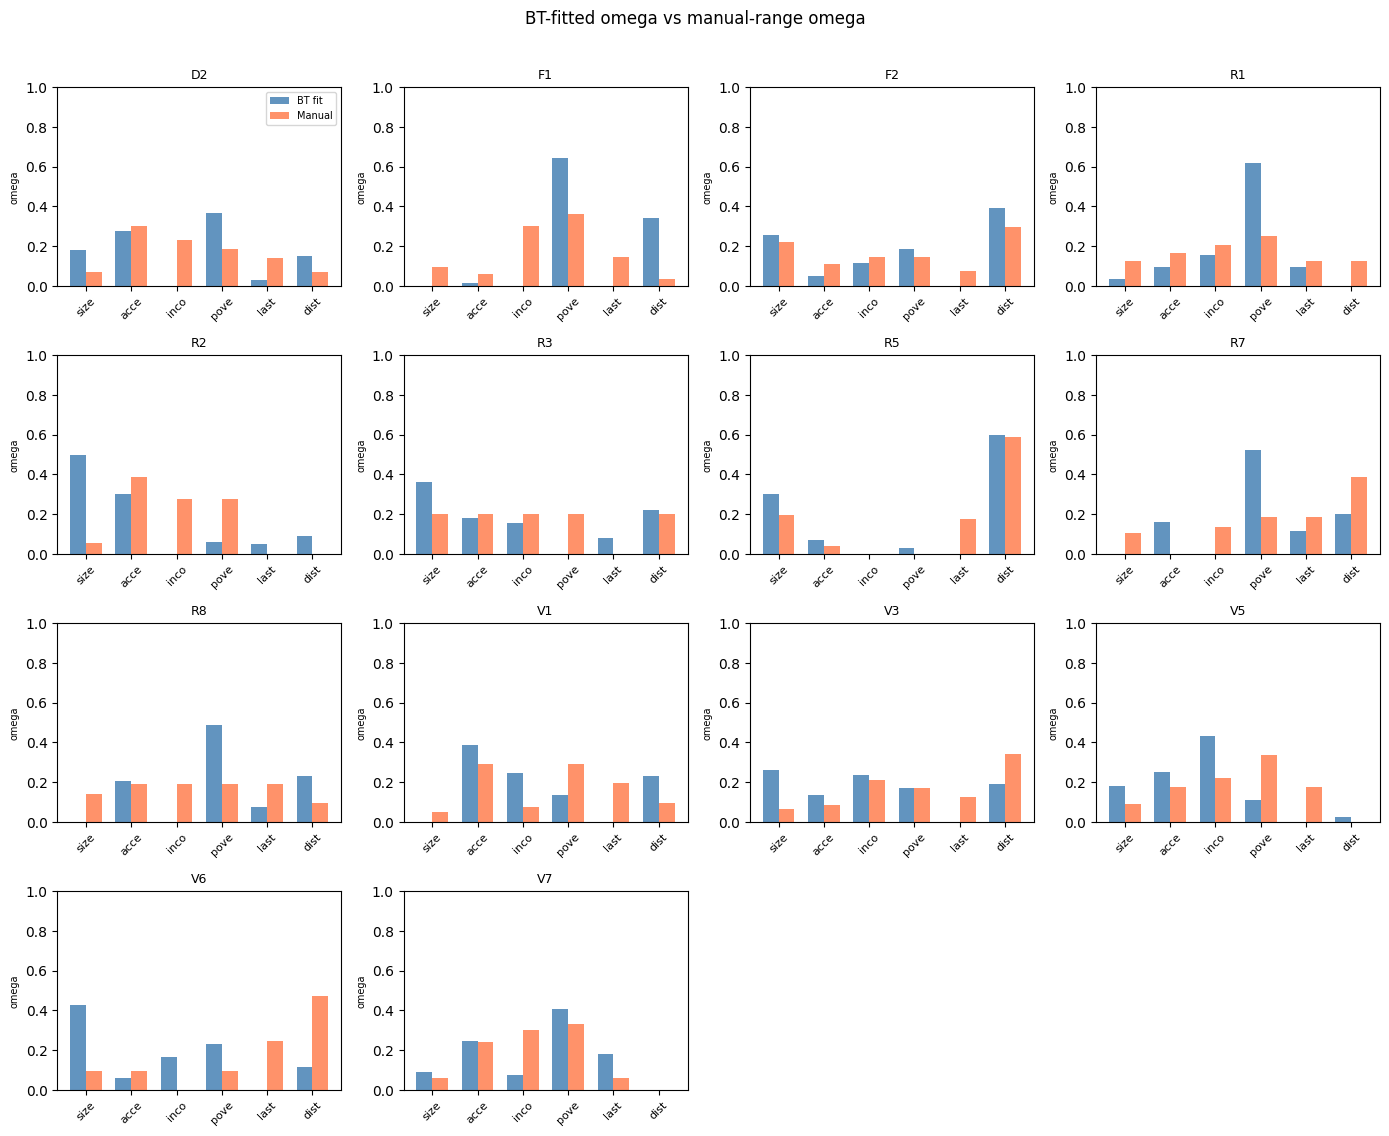

Saved bt_omega_vs_manual.png


In [9]:
# Side-by-side bar chart: BT omega vs manual omega for persons with both
pids_both = [p for p in persons if omega_manual[p] is not None]
n2 = len(pids_both)
ncols2, nrows2 = 4, (n2 + 3) // 4

fig, axes = plt.subplots(nrows2, ncols2, figsize=(ncols2 * 3.5, nrows2 * 2.8))
axes = axes.flatten()

x = np.arange(len(FEATURES))
w = 0.35

for ax, pid in zip(axes, pids_both):
    om_bt  = results[pid]['omega']
    om_man = omega_manual[pid]
    ax.bar(x - w/2, om_bt,  w, label='BT fit',  color='steelblue', alpha=0.85)
    ax.bar(x + w/2, om_man, w, label='Manual',  color='coral',     alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([f[:4] for f in FEATURES], fontsize=8, rotation=45)
    ax.set_ylim(0, 1)
    ax.set_title(pid, fontsize=9)
    ax.set_ylabel('omega', fontsize=7)

axes[0].legend(fontsize=7)

for ax in axes[n2:]:
    ax.set_visible(False)

plt.suptitle('BT-fitted omega vs manual-range omega', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('bt_omega_vs_manual.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved bt_omega_vs_manual.png')


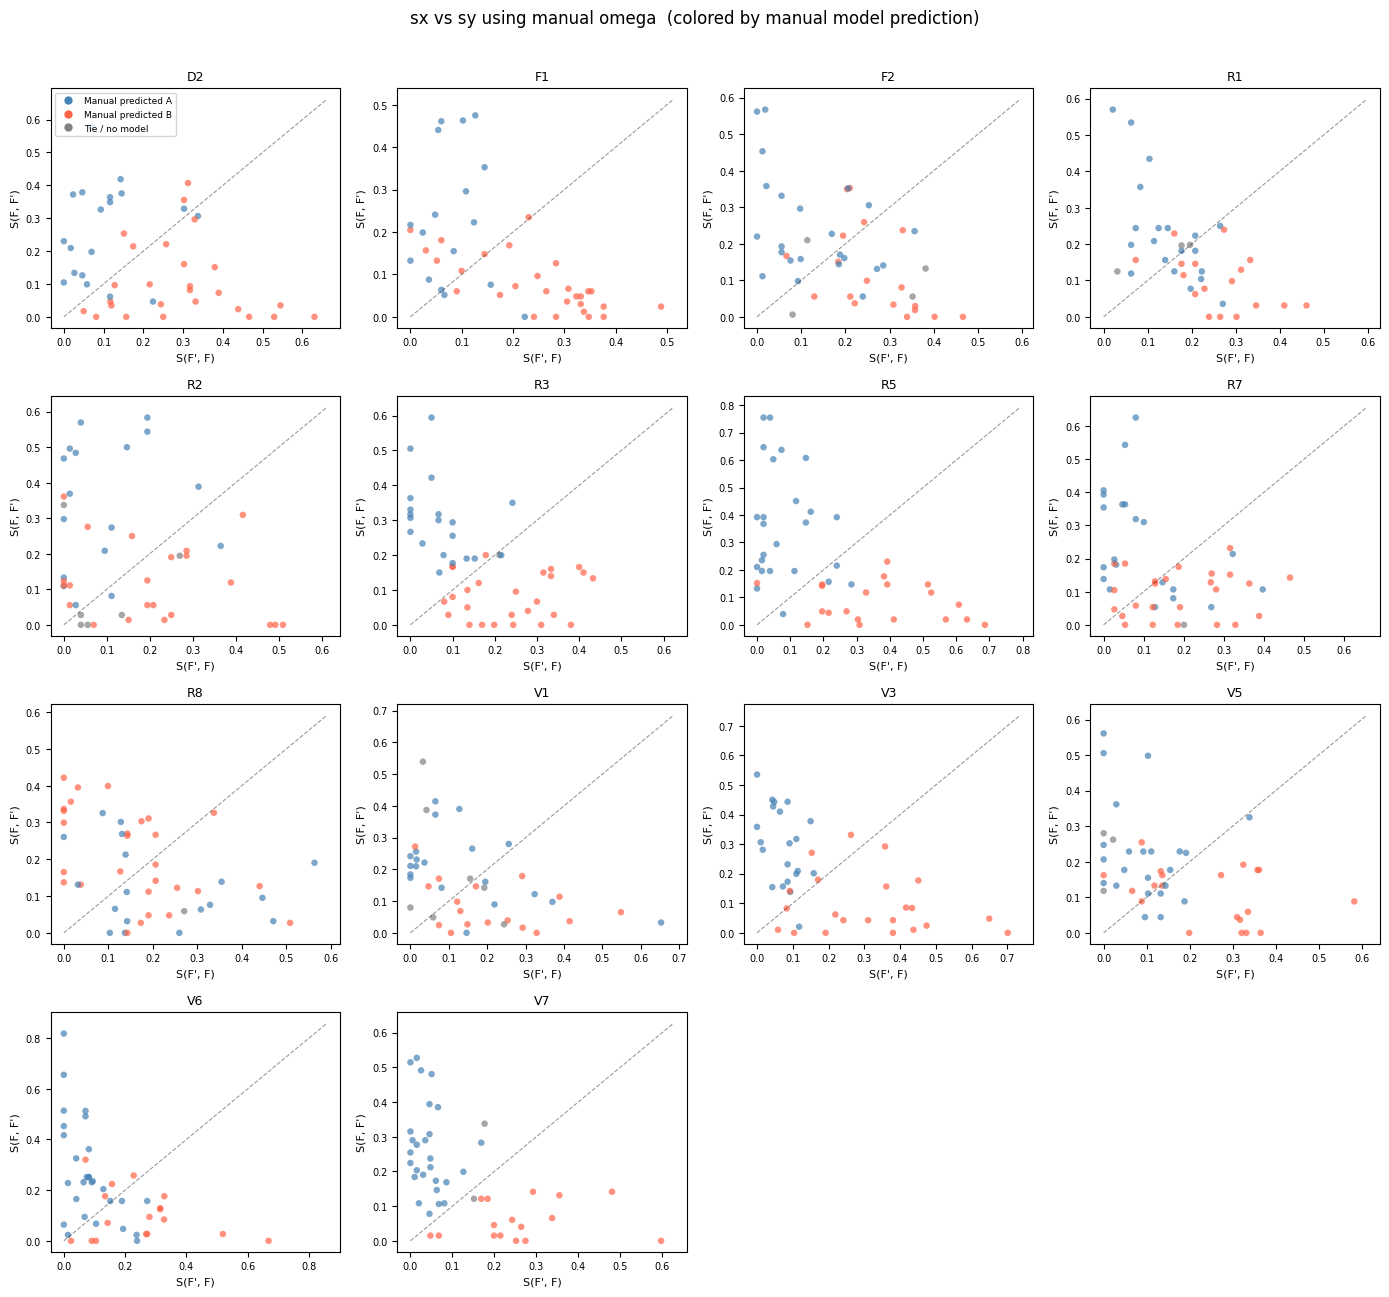

Saved manual_omega_sxsy_manual_pred.png


In [10]:
# pids_manual / grid dimensions are derived from cell 9's pids_both
pids_manual = pids_both
n_m       = len(pids_manual)
ncols_m   = 4
nrows_m   = (n_m + ncols_m - 1) // ncols_m

# sx vs sy using manual omega, colored by MANUAL MODEL prediction
preds = pd.read_csv('pairwise_model_predictions.csv')[['personID','num_Q','model_prediction']]
# deduplicate: some persons have multiple rows per num_Q (different food types)
preds_dedup = preds.drop_duplicates(subset=['personID','num_Q'])

fig, axes = plt.subplots(nrows_m, ncols_m, figsize=(ncols_m * 3.5, nrows_m * 3.2))
axes = axes.flatten()

for ax, pid in zip(axes, pids_manual):
    omega = omega_manual[pid]
    sub   = results[pid]['sub']
    dx    = sub[dx_cols].values

    dx_norm = dx / DX_SCALE
    r     = (np.abs(dx_norm) * omega).sum(axis=1)
    kappa = (dx_norm * omega).sum(axis=1)
    sy    = (r + kappa) / 2
    sx    = (r - kappa) / 2

    # Build num_Q -> model_prediction lookup for this person
    lookup = preds_dedup[preds_dedup['personID'] == pid].set_index('num_Q')['model_prediction']
    pred_col = sub['num_Q'].map(lookup)
    colors_pt = [choice_color.get(c, 'gray') for c in pred_col]

    ax.scatter(sx, sy, c=colors_pt, alpha=0.7, s=22, linewidths=0)

    lim = max(sx.max(), sy.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'k--', lw=0.8, alpha=0.4)

    ax.set_xlabel("S(F', F)", fontsize=8)
    ax.set_ylabel("S(F, F')", fontsize=8)
    ax.set_title(pid, fontsize=9)
    ax.tick_params(labelsize=7)

legend_els = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue',
           markersize=7, label='Manual predicted A'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='tomato',
           markersize=7, label='Manual predicted B'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='gray',
           markersize=7, label='Tie / no model'),
]
axes[0].legend(handles=legend_els, fontsize=6.5, loc='upper left')

for ax in axes[n_m:]:
    ax.set_visible(False)

plt.suptitle('sx vs sy using manual omega  (colored by manual model prediction)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('manual_omega_sxsy_manual_pred.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved manual_omega_sxsy_manual_pred.png')


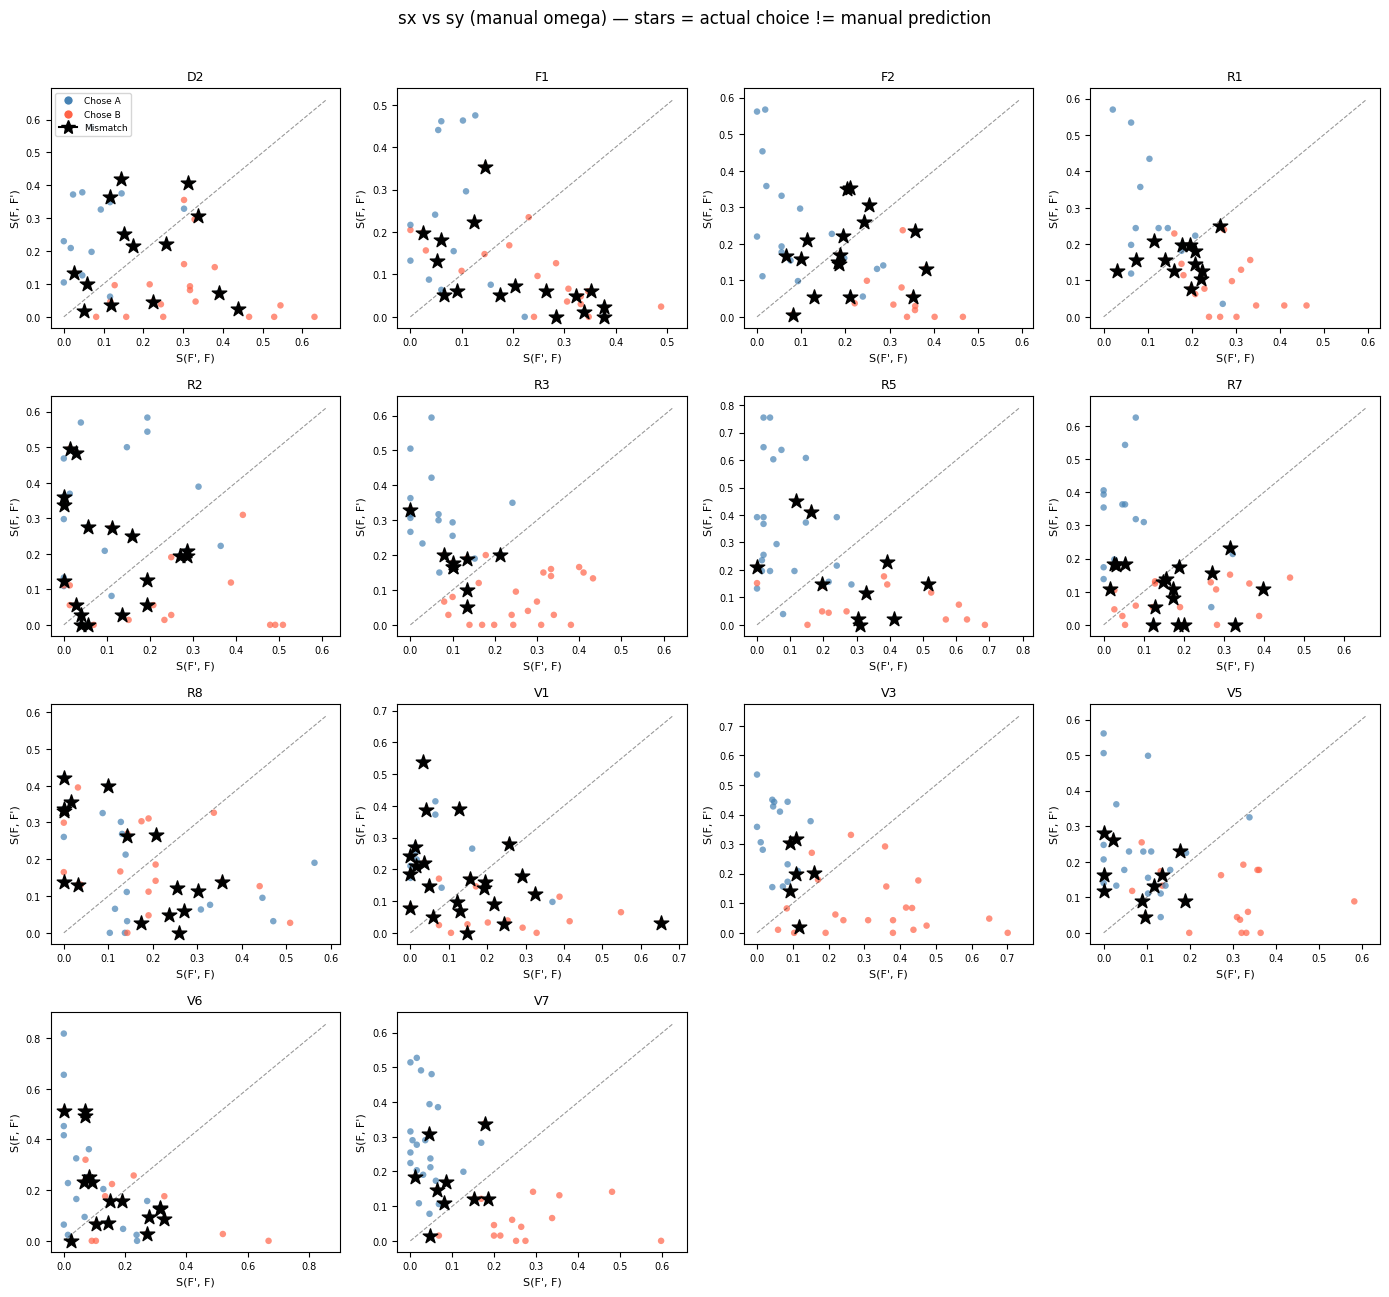

Saved manual_omega_sxsy_mismatches.png


In [11]:
# sx vs sy (manual omega, colored by actual choice) with stars on mismatches
preds_dedup = pd.read_csv('pairwise_model_predictions.csv')[['personID','num_Q','model_prediction']] \
    .drop_duplicates(subset=['personID','num_Q'])

fig, axes = plt.subplots(nrows_m, ncols_m, figsize=(ncols_m * 3.5, nrows_m * 3.2))
axes = axes.flatten()

for ax, pid in zip(axes, pids_manual):
    omega = omega_manual[pid]
    sub   = results[pid]['sub']
    dx    = sub[dx_cols].values
    choice = results[pid]['choice']

    dx_norm = dx / DX_SCALE
    r     = (np.abs(dx_norm) * omega).sum(axis=1)
    kappa = (dx_norm * omega).sum(axis=1)
    sy    = (r + kappa) / 2
    sx    = (r - kappa) / 2

    # Base scatter colored by actual choice
    colors_pt = [choice_color.get(c, 'gray') for c in choice]
    ax.scatter(sx, sy, c=colors_pt, alpha=0.7, s=22, linewidths=0)

    lim = max(sx.max(), sy.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'k--', lw=0.8, alpha=0.4)

    # Star queries where actual choice != manual model prediction
    lookup = preds_dedup[preds_dedup['personID'] == pid].set_index('num_Q')['model_prediction']
    pred_col = sub['num_Q'].map(lookup).values
    mismatch_mask = np.array([
        c != p if (pd.notna(p) and pd.notna(c)) else False
        for c, p in zip(choice, pred_col)
    ])
    if mismatch_mask.any():
        ax.scatter(sx[mismatch_mask], sy[mismatch_mask],
                   marker='*', s=120, color='black', zorder=5)

    ax.set_xlabel("S(F', F)", fontsize=8)
    ax.set_ylabel("S(F, F')", fontsize=8)
    ax.set_title(pid, fontsize=9)
    ax.tick_params(labelsize=7)

legend_els = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue',
           markersize=7, label='Chose A'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='tomato',
           markersize=7, label='Chose B'),
    Line2D([0],[0], marker='*', color='black', markersize=10, label='Mismatch'),
]
axes[0].legend(handles=legend_els, fontsize=6.5, loc='upper left')

for ax in axes[n_m:]:
    ax.set_visible(False)

plt.suptitle('sx vs sy (manual omega) — stars = actual choice != manual prediction',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('manual_omega_sxsy_mismatches.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved manual_omega_sxsy_mismatches.png')


          n_mismatch  pct_mismatch  n_conflicted  pct_conflicted  avg_difficulty
personID                                                                        
D2                14          31.1             2             4.4             1.1
R3                 8          17.4             1             2.2             1.1
R7                16          34.8             4             8.0             1.2
R8                15          32.6             2             4.9             1.1
V3                 8          17.8             8            18.6             2.2
V5                 7          16.3            15            37.5             2.5


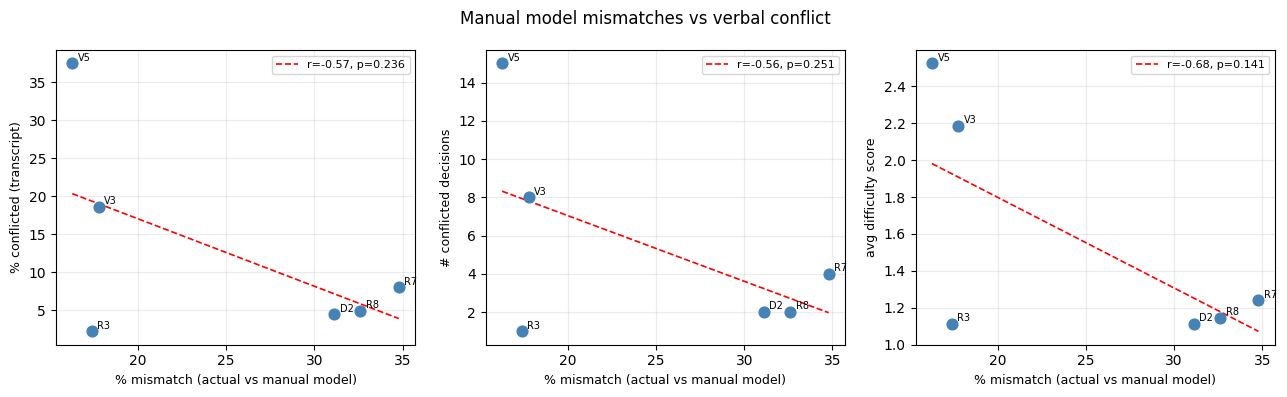

Saved mismatch_vs_conflict.png


In [12]:
# Compare mismatches per person vs verbal conflict score
import scipy.stats as stats

# --- mismatch counts (exclude ties and NaN) ---
pm = pd.read_csv('pairwise_model_predictions.csv')
pm = pm.drop_duplicates(subset=['personID','num_Q'])  # one row per comparison
pm['matches_actual'] = pm['matches_actual'].map({'True': True, 'False': False, True: True, False: False})
pm_valid = pm[pm['model_prediction'] != 'tie'].dropna(subset=['matches_actual'])
mismatch_counts = pm_valid.groupby('personID').agg(
    n_compared=('matches_actual', 'count'),
    n_mismatch=('matches_actual', lambda x: (~x.astype(bool)).sum()),
).assign(pct_mismatch=lambda d: d['n_mismatch'] / d['n_compared'] * 100)

# --- verbal conflict scores ---
td = pd.read_csv('transcript_difficulty.csv')
verbal = td.groupby('personID').agg(
    n_decisions=('num_Q', 'count'),
    n_conflicted=('conflicted', 'sum'),
    avg_difficulty=('difficulty_score', 'mean'),
).assign(pct_conflicted=lambda d: d['n_conflicted'] / d['n_decisions'] * 100)

# --- merge ---
cmp = mismatch_counts.join(verbal, how='inner')
print(cmp[['n_mismatch','pct_mismatch','n_conflicted','pct_conflicted','avg_difficulty']].round(1).to_string())

# --- scatter plots ---
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

pairs = [
    ('pct_mismatch',  'pct_conflicted',  '% conflicted (transcript)'),
    ('pct_mismatch',  'n_conflicted',    '# conflicted decisions'),
    ('pct_mismatch',  'avg_difficulty',  'avg difficulty score'),
]

for ax, (xcol, ycol, ylabel) in zip(axes, pairs):
    x = cmp[xcol].values
    y = cmp[ycol].values
    ax.scatter(x, y, color='steelblue', s=60, zorder=3)

    for pid, row in cmp.iterrows():
        ax.annotate(pid, (row[xcol], row[ycol]),
                    fontsize=7, xytext=(4, 2), textcoords='offset points')

    # regression line
    m, b, r, p, _ = stats.linregress(x, y)
    xfit = np.linspace(x.min(), x.max(), 100)
    ax.plot(xfit, m * xfit + b, 'r--', lw=1.2,
            label=f'r={r:.2f}, p={p:.3f}')
    ax.legend(fontsize=8)

    ax.set_xlabel('% mismatch (actual vs manual model)', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.grid(True, alpha=0.25)

plt.suptitle('Manual model mismatches vs verbal conflict', fontsize=12)
plt.tight_layout()
plt.savefig('mismatch_vs_conflict.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved mismatch_vs_conflict.png')


## Distance to diagonal: mismatched (★) vs consistent queries — manual ω **and** BT-learned ω

For each query, an $(s_x, s_y)$ pair is computed *given a choice of $\omega$*:

$$r = (|\Delta x_\text{norm}| \cdot \omega).\text{sum},\qquad \kappa = (\Delta x_\text{norm} \cdot \omega).\text{sum}, \qquad s_y = \tfrac{r+\kappa}{2},\quad s_x = \tfrac{r-\kappa}{2}$$

The **orthogonal projection distance** to the diagonal $s_y = s_x$ is

$$d = \frac{|s_y - s_x|}{\sqrt{2}} = \frac{|\kappa|}{\sqrt{2}}.$$

Large $d$ means the model (under that $\omega$) was decisive about the query; small $d$ means it was near-tie.

We compute this under **two ω choices**:

- **Manual ω** — the score-range-derived ω from each participant's manual scoring sheet.
- **BT ω** — the omega fit by Bradley–Terry MLE on that participant's decisive responses.

Mismatches (★) are queries where the participant's actual choice $\ne$ the **manual** model's prediction (the same definition as in the mismatch plot above). The mismatch label is fixed; only the geometry $(s_x, s_y, d)$ changes between the two ω choices.

The two views answer different questions:

- **Under manual ω**: are mismatches concentrated where the *manual* model was already uncertain?
- **Under BT ω**: are mismatches concentrated where the *BT-learned* model is uncertain — i.e., did BT learn to "soften" its decisiveness on the queries that became mismatches?


Distance-to-diagonal stats by ω choice

Under MANUAL ω
════════════════════════════════════════════════════════════════════════════════════
group                              n    mean d   median d     std d     min     max
────────────────────────────────────────────────────────────────────────────────────
Mismatch (black stars ★)         166    0.1081     0.0857    0.0858  0.0000  0.4388
Consistent (non-stars)           435    0.1584     0.1404    0.1123  0.0004  0.5783
All queries                      601    0.1445     0.1225    0.1079  0.0000  0.5783

Statistical tests (mismatches vs consistent)
────────────────────────────────────────────────────────────
  Mean difference (★ − non-★):  -0.0503  (Cohen's d = -0.476)
  Welch's t-test:               t = -5.877    p = 0.0000
  Mann–Whitney U:                U = 26306    p = 0.0000
  → mismatches are closer to the diagonal than consistent queries (significant at α=0.05).

Under BT-LEARNED ω
═════════════════════════════════════════════

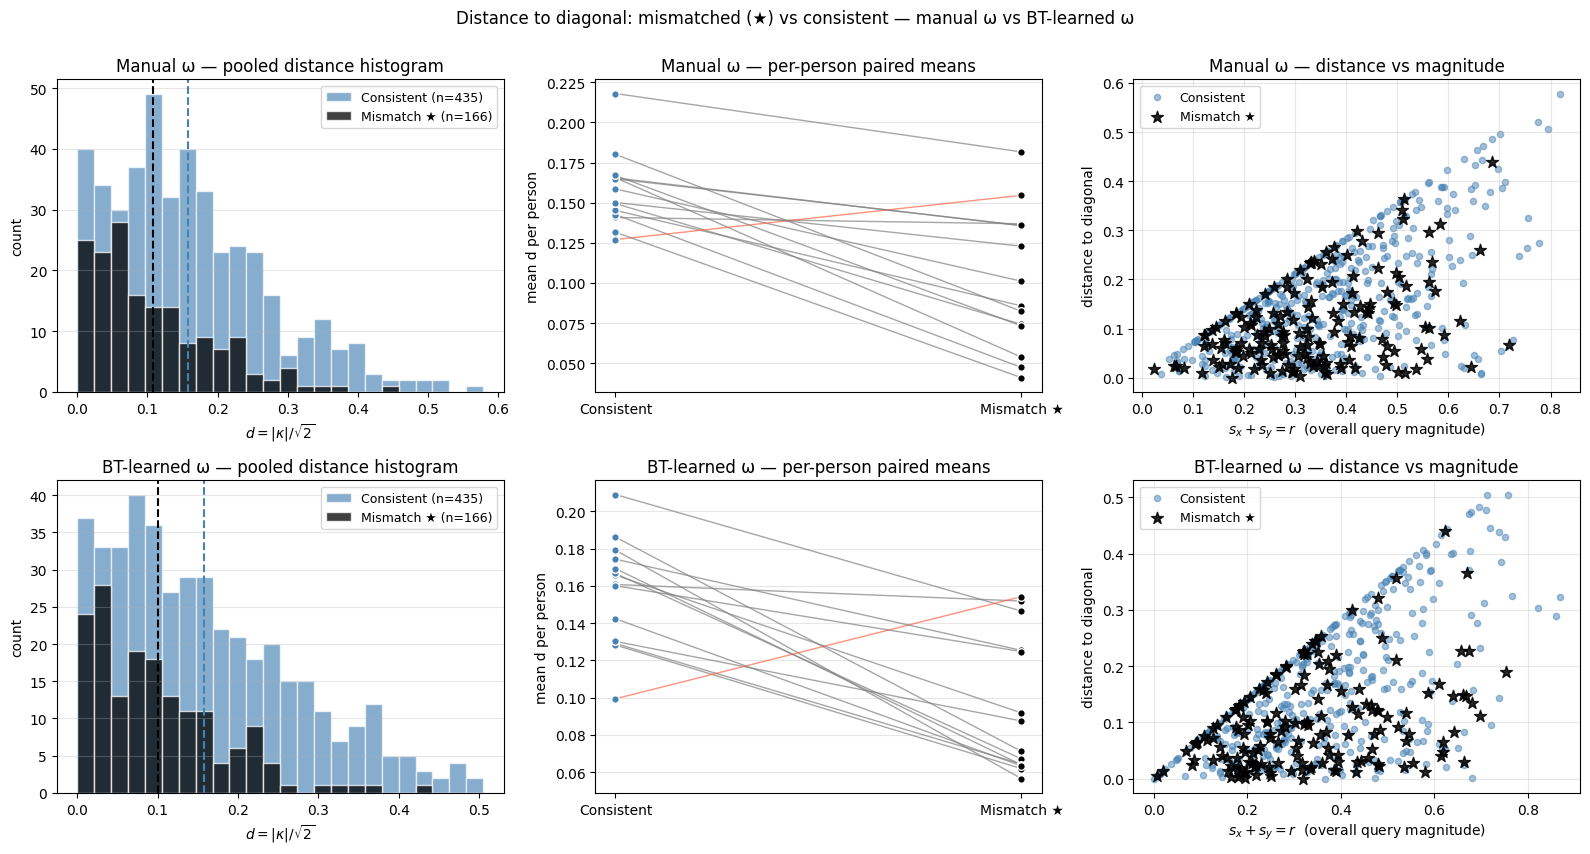


Saved mismatch_distance_to_diagonal.png


In [13]:
# ─── Distance-to-diagonal: ★ vs non-★, under manual ω AND BT-learned ω ──────
import numpy as np
import pandas as pd
from scipy import stats

preds_dedup = pd.read_csv('pairwise_model_predictions.csv')[
    ['personID', 'num_Q', 'model_prediction']
].drop_duplicates(subset=['personID', 'num_Q'])

def _build_records(omega_source: dict, omega_label: str):
    """Returns a DataFrame with one row per (person, query): sx, sy, d, mismatch, valid."""
    rows = []
    for pid in pids_manual:
        omega = omega_source[pid]
        if omega is None:
            continue
        sub    = results[pid]['sub']
        dx     = sub[dx_cols].values
        choice = results[pid]['choice']

        dx_norm = dx / DX_SCALE
        r       = (np.abs(dx_norm) * omega).sum(axis=1)
        kappa   = (dx_norm * omega).sum(axis=1)
        sy      = (r + kappa) / 2
        sx      = (r - kappa) / 2
        d_diag  = np.abs(sy - sx) / np.sqrt(2.0)

        lookup   = preds_dedup[preds_dedup['personID'] == pid].set_index('num_Q')['model_prediction']
        pred_col = sub['num_Q'].map(lookup).values
        mismatch_mask = np.array([
            c != p if (pd.notna(p) and pd.notna(c)) else False
            for c, p in zip(choice, pred_col)
        ])
        valid_mask = np.array([pd.notna(p) and p != 'tie' and pd.notna(c)
                               for c, p in zip(choice, pred_col)])

        for q, _r, _k, _sx, _sy, _d, _mm, _v in zip(
                sub['num_Q'].values, r, kappa, sx, sy, d_diag, mismatch_mask, valid_mask):
            rows.append({
                'personID':    pid,
                'num_Q':       int(q),
                'sx':          float(_sx),
                'sy':          float(_sy),
                'kappa':       float(_k),
                'dist':        float(_d),
                'mismatch':    bool(_mm),
                'valid':       bool(_v),
                'omega_src':   omega_label,
            })
    return pd.DataFrame(rows)


# Build BT-omega dict in the same shape as omega_manual
omega_bt = {pid: results[pid]['omega'] for pid in pids_manual}

qdf_man = _build_records(omega_manual, 'manual')
qdf_bt  = _build_records(omega_bt,     'BT')

def _summary(qdf, label):
    qv = qdf[qdf['valid']]
    s  = qv.loc[qv['mismatch'],  'dist'].values
    o  = qv.loc[~qv['mismatch'], 'dist'].values
    print(f'\n{label}')
    print('═' * 84)
    print(f'{"group":30s}  {"n":>4s}  {"mean d":>8s}  {"median d":>9s}  {"std d":>8s}  {"min":>6s}  {"max":>6s}')
    print('─' * 84)
    def _row(lbl, x):
        if len(x) == 0:
            print(f'{lbl:30s}  {0:>4d}  {"—":>8s}  {"—":>9s}  {"—":>8s}  {"—":>6s}  {"—":>6s}')
            return
        print(f'{lbl:30s}  {len(x):>4d}  {x.mean():>8.4f}  {np.median(x):>9.4f}  {x.std(ddof=1):>8.4f}  {x.min():>6.4f}  {x.max():>6.4f}')
    _row('Mismatch (black stars ★)', s)
    _row('Consistent (non-stars)',  o)
    _row('All queries',              qv['dist'].values)

    if len(s) >= 2 and len(o) >= 2:
        t_stat, t_p = stats.ttest_ind(s, o, equal_var=False)
        u_stat, u_p = stats.mannwhitneyu(s, o, alternative='two-sided')
        diff_mean = float(s.mean() - o.mean())
        pooled_sd = float(np.sqrt(((len(s)-1)*s.var(ddof=1) +
                                   (len(o)-1)*o.var(ddof=1))
                                  / (len(s) + len(o) - 2)))
        cohens_d  = diff_mean / pooled_sd if pooled_sd > 0 else float('nan')
        print('\nStatistical tests (mismatches vs consistent)')
        print('─' * 60)
        print(f'  Mean difference (★ − non-★):  {diff_mean:+.4f}  (Cohen\'s d = {cohens_d:+.3f})')
        print(f'  Welch\'s t-test:               t = {t_stat:+.3f}    p = {t_p:.4f}')
        print(f'  Mann–Whitney U:                U = {u_stat:.0f}    p = {u_p:.4f}')
        direction = 'farther from' if diff_mean > 0 else 'closer to'
        sig       = 'significant' if t_p < 0.05 else 'not significant'
        print(f'  → mismatches are {direction} the diagonal than consistent queries ({sig} at α=0.05).')
    return s, o

print('Distance-to-diagonal stats by ω choice')
stars_man, others_man = _summary(qdf_man, 'Under MANUAL ω')
stars_bt,  others_bt  = _summary(qdf_bt,  'Under BT-LEARNED ω')

# ── Side-by-side comparison table ───────────────────────────────────────────
print('\nSide-by-side comparison')
print('═' * 80)
print(f'{"":35s}  {"Manual ω":>15s}  {"BT ω":>15s}')
print('─' * 80)
for lbl, vals in [
    ('Mean d (★)',             (stars_man.mean(),   stars_bt.mean())),
    ('Mean d (non-★)',         (others_man.mean(),  others_bt.mean())),
    ('Median d (★)',           (np.median(stars_man),  np.median(stars_bt))),
    ('Median d (non-★)',       (np.median(others_man), np.median(others_bt))),
    ('Δmean (★ − non-★)',      (stars_man.mean()-others_man.mean(),
                                stars_bt.mean()-others_bt.mean())),
]:
    print(f'{lbl:35s}  {vals[0]:>+15.4f}  {vals[1]:>+15.4f}')

# ── Per-person Δmean comparison (paired Wilcoxon under each ω) ──────────────
def _per_person_deltas(qdf):
    qv = qdf[qdf['valid']]
    out = []
    for pid in pids_manual:
        sub = qv[qv['personID'] == pid]
        s = sub.loc[sub['mismatch'],  'dist'].values
        o = sub.loc[~sub['mismatch'], 'dist'].values
        if len(s) > 0 and len(o) > 0:
            out.append({'pid': pid, 'delta': s.mean() - o.mean(),
                        'mean_star': s.mean(), 'mean_other': o.mean()})
    return pd.DataFrame(out)

pp_man = _per_person_deltas(qdf_man)
pp_bt  = _per_person_deltas(qdf_bt)

print('\nPer-person Δmean (★ − non-★) under each ω')
print('═' * 60)
print(f'{"person":>8s}  {"Δ manual ω":>12s}  {"Δ BT ω":>10s}')
print('─' * 60)
merged = pp_man.merge(pp_bt, on='pid', suffixes=('_man', '_bt'))
for _, row in merged.iterrows():
    print(f'{row["pid"]:>8s}  {row["delta_man"]:>+12.4f}  {row["delta_bt"]:>+10.4f}')
print('─' * 60)
print(f'  ★ closer (Δ < 0):  manual ω: {(merged["delta_man"] < 0).sum()} / {len(merged)}    '
      f'BT ω: {(merged["delta_bt"] < 0).sum()} / {len(merged)}')
if len(merged) >= 3:
    w_man, p_man = stats.wilcoxon(merged['delta_man'])
    w_bt,  p_bt  = stats.wilcoxon(merged['delta_bt'])
    print(f'  Wilcoxon signed-rank:  manual ω: W = {w_man:.1f}, p = {p_man:.4f}    '
          f'BT ω: W = {w_bt:.1f}, p = {p_bt:.4f}')

# ── Plot: 2x3 grid (manual ω top row, BT ω bottom row) ──────────────────────
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 3, figsize=(16, 8.5))

def _plot_panel(qdf, axes_row, title_prefix):
    qv = qdf[qdf['valid']]
    s  = qv.loc[qv['mismatch'],  'dist'].values
    o  = qv.loc[~qv['mismatch'], 'dist'].values

    # Panel 1: histogram
    ax = axes_row[0]
    bins = np.linspace(0, max(qv['dist'].max(), 1e-3), 25)
    ax.hist(o, bins=bins, color='steelblue', alpha=0.65,
            label=f'Consistent (n={len(o)})', edgecolor='white')
    ax.hist(s, bins=bins, color='black',     alpha=0.75,
            label=f'Mismatch ★ (n={len(s)})', edgecolor='white')
    ax.axvline(o.mean(), color='steelblue', ls='--', lw=1.5)
    ax.axvline(s.mean(), color='black',     ls='--', lw=1.5)
    ax.set_xlabel(r'$d = |\kappa|/\sqrt{2}$')
    ax.set_ylabel('count')
    ax.set_title(f'{title_prefix} — pooled distance histogram')
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

    # Panel 2: per-person paired means
    ax = axes_row[1]
    pp = _per_person_deltas(qdf)
    for _, row in pp.iterrows():
        ax.plot([0, 1], [row['mean_other'], row['mean_star']], '-',
                color=('tomato' if row['delta'] > 0 else 'gray'), alpha=0.7, lw=1.0)
        ax.scatter([0], [row['mean_other']], s=30, color='steelblue', zorder=5, edgecolor='white')
        ax.scatter([1], [row['mean_star']],  s=30, color='black',     zorder=5, edgecolor='white')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Consistent', 'Mismatch ★'])
    ax.set_ylabel('mean d per person')
    ax.set_title(f'{title_prefix} — per-person paired means')
    ax.grid(axis='y', alpha=0.3)

    # Panel 3: distance vs query magnitude
    ax = axes_row[2]
    cons = qv[~qv['mismatch']]
    mism = qv[ qv['mismatch']]
    ax.scatter(cons['sx'] + cons['sy'], cons['dist'],
               c='steelblue', alpha=0.5, s=20, label='Consistent')
    ax.scatter(mism['sx'] + mism['sy'], mism['dist'],
               marker='*', s=80, c='black', alpha=0.85, label='Mismatch ★', zorder=5)
    ax.set_xlabel(r'$s_x + s_y = r$  (overall query magnitude)')
    ax.set_ylabel('distance to diagonal')
    ax.set_title(f'{title_prefix} — distance vs magnitude')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

_plot_panel(qdf_man, axes[0], 'Manual ω')
_plot_panel(qdf_bt,  axes[1], 'BT-learned ω')

plt.suptitle('Distance to diagonal: mismatched (★) vs consistent — manual ω vs BT-learned ω',
             fontsize=12, y=1.00)
plt.tight_layout()
plt.savefig('mismatch_distance_to_diagonal.png', dpi=120, bbox_inches='tight')
plt.show()
print('\nSaved mismatch_distance_to_diagonal.png')


## Total decision magnitude $r$ and distance along the diagonal — mismatched (★) vs consistent

Distance to the diagonal captures *decisiveness*; total magnitude captures *how big the decision is at all*.

For each query under a chosen $\omega$:

$$r = (|\Delta x_\text{norm}| \cdot \omega).\text{sum} = s_x + s_y$$

The **projection onto the diagonal** $s_y = s_x$ is the point $((s_x+s_y)/2,\, (s_x+s_y)/2)$, so the **Euclidean distance from the origin to that projection** is

$$d_\parallel = \frac{s_x + s_y}{\sqrt{2}} = \frac{r}{\sqrt{2}}.$$

Geometrically, $d_\parallel$ is "how far down the diagonal we are after projecting onto it." Since $d_\parallel = r/\sqrt{2}$, the two are proportional and the t-tests / rank tests give identical p-values; only the absolute scale of mean differences changes by $\sqrt{2}$.

We split queries by mismatch (actual choice $\ne$ manual prediction, same definition as before) and compute stats under **both manual ω** and **BT-learned ω**.

The hypothesis: are mismatches concentrated on *small* queries (low overall feature gap) or *large* queries (the participant disagrees even when the gap is big)?


STATS ON r (= sx + sy)

Under MANUAL ω  —  metric: r
════════════════════════════════════════════════════════════════════════════════════
group                              n      mean    median       std     min     max
────────────────────────────────────────────────────────────────────────────────────
Mismatch (★)                     166    0.3335    0.3234    0.1383  0.0236  0.7193
Consistent                       435    0.3655    0.3543    0.1614  0.0371  0.8178
All queries                      601    0.3567    0.3430    0.1559  0.0236  0.8178

Statistical tests
────────────────────────────────────────────────────────────
  Mean diff (★ − non-★):  -0.0320  (Cohen's d = -0.206)
  Welch's t-test:         t = -2.418    p = 0.0161
  Mann–Whitney U:          U = 32208    p = 0.0407
  → mismatches have smaller r than consistent queries (significant at α=0.05).

Under BT-LEARNED ω  —  metric: r
════════════════════════════════════════════════════════════════════════════════════
group    

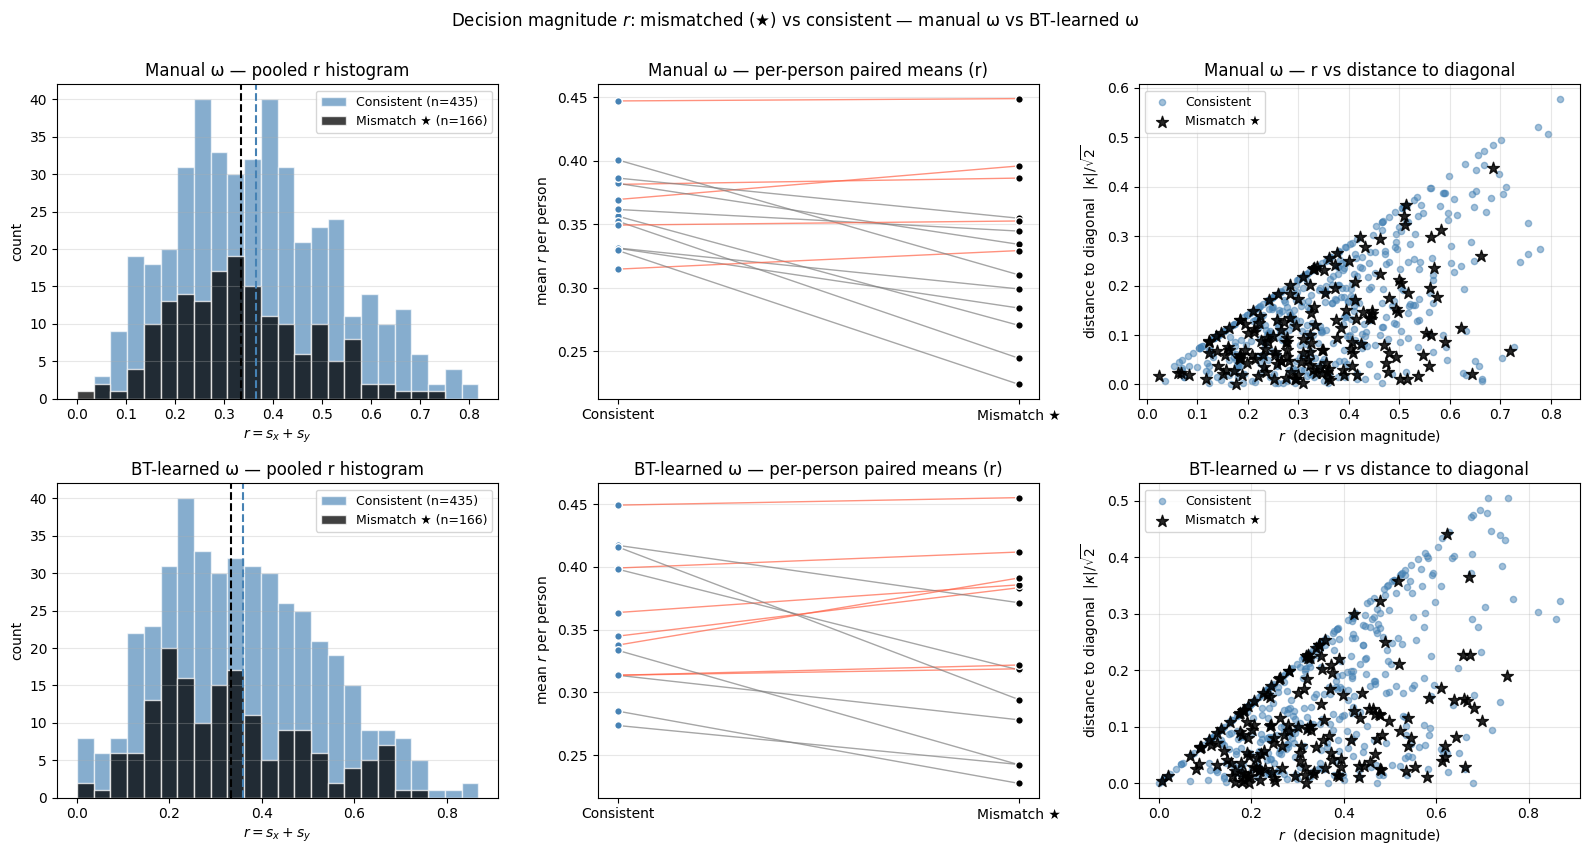


Saved mismatch_r_magnitude.png


In [14]:
# ─── Stats on r (= sx + sy) and d_∥ (= r/√2) for ★ vs non-★, both ω choices ─
import numpy as np
import pandas as pd
from scipy import stats

preds_dedup = pd.read_csv('pairwise_model_predictions.csv')[
    ['personID', 'num_Q', 'model_prediction']
].drop_duplicates(subset=['personID', 'num_Q'])


def _build_records_r(omega_source: dict, omega_label: str):
    """One row per (person, query): sx, sy, r, d_along, mismatch, valid."""
    rows = []
    for pid in pids_manual:
        omega = omega_source[pid]
        if omega is None:
            continue
        sub    = results[pid]['sub']
        dx     = sub[dx_cols].values
        choice = results[pid]['choice']

        dx_norm = dx / DX_SCALE
        r       = (np.abs(dx_norm) * omega).sum(axis=1)
        kappa   = (dx_norm * omega).sum(axis=1)
        sy      = (r + kappa) / 2
        sx      = (r - kappa) / 2
        d_along = (sx + sy) / np.sqrt(2.0)   # = r / √2

        lookup   = preds_dedup[preds_dedup['personID'] == pid].set_index('num_Q')['model_prediction']
        pred_col = sub['num_Q'].map(lookup).values
        mismatch_mask = np.array([
            c != p if (pd.notna(p) and pd.notna(c)) else False
            for c, p in zip(choice, pred_col)
        ])
        valid_mask = np.array([pd.notna(p) and p != 'tie' and pd.notna(c)
                               for c, p in zip(choice, pred_col)])

        for q, _r, _da, _sx, _sy, _mm, _v in zip(
                sub['num_Q'].values, r, d_along, sx, sy, mismatch_mask, valid_mask):
            rows.append({
                'personID': pid, 'num_Q': int(q),
                'sx': float(_sx), 'sy': float(_sy),
                'r': float(_r), 'd_along': float(_da),
                'mismatch': bool(_mm), 'valid': bool(_v),
                'omega_src': omega_label,
            })
    return pd.DataFrame(rows)


omega_bt = {pid: results[pid]['omega'] for pid in pids_manual}
qdf_man = _build_records_r(omega_manual, 'manual')
qdf_bt  = _build_records_r(omega_bt,     'BT')


def _summary(qdf, label, col):
    qv = qdf[qdf['valid']]
    s  = qv.loc[qv['mismatch'],  col].values
    o  = qv.loc[~qv['mismatch'], col].values
    print(f'\n{label}  —  metric: {col}')
    print('═' * 84)
    print(f'{"group":30s}  {"n":>4s}  {"mean":>8s}  {"median":>8s}  {"std":>8s}  {"min":>6s}  {"max":>6s}')
    print('─' * 84)
    def _row(lbl, x):
        if len(x) == 0:
            print(f'{lbl:30s}  {0:>4d}  {"—":>8s}  {"—":>8s}  {"—":>8s}  {"—":>6s}  {"—":>6s}')
            return
        print(f'{lbl:30s}  {len(x):>4d}  {x.mean():>8.4f}  {np.median(x):>8.4f}  {x.std(ddof=1):>8.4f}  {x.min():>6.4f}  {x.max():>6.4f}')
    _row('Mismatch (★)',   s)
    _row('Consistent',      o)
    _row('All queries',     qv[col].values)

    if len(s) >= 2 and len(o) >= 2:
        t_stat, t_p = stats.ttest_ind(s, o, equal_var=False)
        u_stat, u_p = stats.mannwhitneyu(s, o, alternative='two-sided')
        diff_mean   = float(s.mean() - o.mean())
        pooled_sd   = float(np.sqrt(((len(s)-1)*s.var(ddof=1) +
                                     (len(o)-1)*o.var(ddof=1))
                                    / (len(s) + len(o) - 2)))
        cohens_d    = diff_mean / pooled_sd if pooled_sd > 0 else float('nan')
        print('\nStatistical tests')
        print('─' * 60)
        print(f'  Mean diff (★ − non-★):  {diff_mean:+.4f}  (Cohen\'s d = {cohens_d:+.3f})')
        print(f'  Welch\'s t-test:         t = {t_stat:+.3f}    p = {t_p:.4f}')
        print(f'  Mann–Whitney U:          U = {u_stat:.0f}    p = {u_p:.4f}')
        direction = 'larger' if diff_mean > 0 else 'smaller'
        sig       = 'significant' if t_p < 0.05 else 'not significant'
        print(f'  → mismatches have {direction} {col} than consistent queries ({sig} at α=0.05).')
    return s, o


print('=' * 84)
print('STATS ON r (= sx + sy)')
print('=' * 84)
r_man_s, r_man_o = _summary(qdf_man, 'Under MANUAL ω',   'r')
r_bt_s,  r_bt_o  = _summary(qdf_bt,  'Under BT-LEARNED ω', 'r')

print('\n' + '=' * 84)
print('STATS ON d_∥ (= r / √2  — distance along the diagonal from origin to projection)')
print('=' * 84)
da_man_s, da_man_o = _summary(qdf_man, 'Under MANUAL ω',   'd_along')
da_bt_s,  da_bt_o  = _summary(qdf_bt,  'Under BT-LEARNED ω', 'd_along')

# ── Side-by-side summary ────────────────────────────────────────────────────
print('\nSide-by-side comparison')
print('═' * 90)
print(f'{"":35s}  {"r — manual ω":>15s}  {"r — BT ω":>13s}  {"d_∥ — manual":>15s}  {"d_∥ — BT":>10s}')
print('─' * 90)
for lbl, vals in [
    ('Mean (★)',          (r_man_s.mean(),          r_bt_s.mean(),          da_man_s.mean(),          da_bt_s.mean())),
    ('Mean (non-★)',      (r_man_o.mean(),          r_bt_o.mean(),          da_man_o.mean(),          da_bt_o.mean())),
    ('Median (★)',        (np.median(r_man_s),      np.median(r_bt_s),      np.median(da_man_s),      np.median(da_bt_s))),
    ('Median (non-★)',    (np.median(r_man_o),      np.median(r_bt_o),      np.median(da_man_o),      np.median(da_bt_o))),
    ('Δmean (★ − non-★)', (r_man_s.mean()  - r_man_o.mean(),
                            r_bt_s.mean()   - r_bt_o.mean(),
                            da_man_s.mean() - da_man_o.mean(),
                            da_bt_s.mean()  - da_bt_o.mean())),
]:
    print(f'{lbl:35s}  {vals[0]:>+15.4f}  {vals[1]:>+13.4f}  {vals[2]:>+15.4f}  {vals[3]:>+10.4f}')

# ── Per-person Δmean comparison (paired Wilcoxon under each ω, on r) ────────
def _per_person_deltas(qdf, col):
    qv = qdf[qdf['valid']]
    out = []
    for pid in pids_manual:
        sub = qv[qv['personID'] == pid]
        s = sub.loc[sub['mismatch'],  col].values
        o = sub.loc[~sub['mismatch'], col].values
        if len(s) > 0 and len(o) > 0:
            out.append({'pid': pid, 'delta': s.mean() - o.mean(),
                        'mean_star': s.mean(), 'mean_other': o.mean()})
    return pd.DataFrame(out)

pp_man_r = _per_person_deltas(qdf_man, 'r')
pp_bt_r  = _per_person_deltas(qdf_bt,  'r')

print('\nPer-person Δmean of r (★ − non-★) under each ω')
print('═' * 60)
print(f'{"person":>8s}  {"Δr manual ω":>13s}  {"Δr BT ω":>10s}')
print('─' * 60)
merged = pp_man_r.merge(pp_bt_r, on='pid', suffixes=('_man', '_bt'))
for _, row in merged.iterrows():
    print(f'{row["pid"]:>8s}  {row["delta_man"]:>+13.4f}  {row["delta_bt"]:>+10.4f}')
print('─' * 60)
n_pos_man = int((merged['delta_man'] > 0).sum())
n_pos_bt  = int((merged['delta_bt']  > 0).sum())
print(f'  ★ has larger r (Δ > 0):   manual ω: {n_pos_man} / {len(merged)}    BT ω: {n_pos_bt} / {len(merged)}')
print(f'  ★ has smaller r (Δ < 0):  manual ω: {len(merged)-n_pos_man} / {len(merged)}    BT ω: {len(merged)-n_pos_bt} / {len(merged)}')
if len(merged) >= 3:
    w_m, p_m = stats.wilcoxon(merged['delta_man'])
    w_b, p_b = stats.wilcoxon(merged['delta_bt'])
    print(f'  Wilcoxon signed-rank:  manual ω: W = {w_m:.1f}, p = {p_m:.4f}    BT ω: W = {w_b:.1f}, p = {p_b:.4f}')

# ── Plot: 2x3 grid (manual ω top, BT ω bottom) on r ─────────────────────────
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 3, figsize=(16, 8.5))

def _plot_panel(qdf, axes_row, title_prefix):
    qv = qdf[qdf['valid']]
    s  = qv.loc[qv['mismatch'],  'r'].values
    o  = qv.loc[~qv['mismatch'], 'r'].values

    # Panel 1: r histogram
    ax = axes_row[0]
    bins = np.linspace(0, max(qv['r'].max(), 1e-3), 25)
    ax.hist(o, bins=bins, color='steelblue', alpha=0.65,
            label=f'Consistent (n={len(o)})', edgecolor='white')
    ax.hist(s, bins=bins, color='black',     alpha=0.75,
            label=f'Mismatch ★ (n={len(s)})', edgecolor='white')
    ax.axvline(o.mean(), color='steelblue', ls='--', lw=1.5)
    ax.axvline(s.mean(), color='black',     ls='--', lw=1.5)
    ax.set_xlabel(r'$r = s_x + s_y$')
    ax.set_ylabel('count')
    ax.set_title(f'{title_prefix} — pooled r histogram')
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

    # Panel 2: per-person paired means of r
    ax = axes_row[1]
    pp = _per_person_deltas(qdf, 'r')
    for _, row in pp.iterrows():
        ax.plot([0, 1], [row['mean_other'], row['mean_star']], '-',
                color=('tomato' if row['delta'] > 0 else 'gray'), alpha=0.7, lw=1.0)
        ax.scatter([0], [row['mean_other']], s=30, color='steelblue', zorder=5, edgecolor='white')
        ax.scatter([1], [row['mean_star']],  s=30, color='black',     zorder=5, edgecolor='white')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Consistent', 'Mismatch ★'])
    ax.set_ylabel(r'mean $r$ per person')
    ax.set_title(f'{title_prefix} — per-person paired means (r)')
    ax.grid(axis='y', alpha=0.3)

    # Panel 3: r vs distance-to-diagonal scatter
    ax = axes_row[2]
    cons = qv[~qv['mismatch']]
    mism = qv[ qv['mismatch']]
    d_cons = np.abs(cons['sy'] - cons['sx']) / np.sqrt(2.0)
    d_mism = np.abs(mism['sy'] - mism['sx']) / np.sqrt(2.0)
    ax.scatter(cons['r'], d_cons,
               c='steelblue', alpha=0.5, s=20, label='Consistent')
    ax.scatter(mism['r'], d_mism,
               marker='*', s=80, c='black', alpha=0.85, label='Mismatch ★', zorder=5)
    ax.set_xlabel(r'$r$  (decision magnitude)')
    ax.set_ylabel(r'distance to diagonal  $|\kappa|/\sqrt{2}$')
    ax.set_title(f'{title_prefix} — r vs distance to diagonal')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

_plot_panel(qdf_man, axes[0], 'Manual ω')
_plot_panel(qdf_bt,  axes[1], 'BT-learned ω')

plt.suptitle(r'Decision magnitude $r$: mismatched (★) vs consistent — manual ω vs BT-learned ω',
             fontsize=12, y=1.00)
plt.tight_layout()
plt.savefig('mismatch_r_magnitude.png', dpi=120, bbox_inches='tight')
plt.show()
print('\nSaved mismatch_r_magnitude.png')
